# OSV Demo On Real F3 SEG-Y Data — 2D (Single Inline)

This notebook does the following:
1. Loads the real SEG-Y seismic volume from `data/F3/1_Original_Seismics.sgy`.
2. Extracts the middle inline section from trace headers (robust for non-perfect SEG-Y geometry).
3. Executes the PyTorch fault-segmentation notebook on the same SEG-Y data and saves the predicted fault-probability inline.
4. Runs **OSV 2D** (Optimal Path Voting) using the fault-segmentation inline as the OSV input attribute.
5. Displays the seismic amplitude, faultSeg output, OSV voting score (`fv`), and the guided thinned OSV result over seismic.

Notes:
- This notebook runs 2D OSV on one representative inline for practical runtime.
- The Java runner accepts an external fault score map so OSV is applied directly to the faultSeg prediction.

In [9]:
import os
import sys
from pathlib import Path
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import segyio

PROJECT_ROOT = Path('/home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV')
SGY_PATH = PROJECT_ROOT / 'data/F3/1_Original_Seismics.sgy'
WORK_DIR = PROJECT_ROOT / 'notebooks' / 'osv_runtime'
WORK_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('SEG-Y file:', SGY_PATH)
print('Exists:', SGY_PATH.exists())

Project root: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV
SEG-Y file: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/data/F3/1_Original_Seismics.sgy
Exists: True


In [10]:
# Extract the middle inline section using header values
with segyio.open(str(SGY_PATH), mode='r', ignore_geometry=True) as f:
    f.mmap()
    il = np.asarray(f.attributes(segyio.TraceField.INLINE_3D)[:])
    xl = np.asarray(f.attributes(segyio.TraceField.CROSSLINE_3D)[:])
    samples = np.asarray(f.samples, dtype=np.float32)

    if il.size == 0:
        raise RuntimeError('No inline headers found in SEG-Y file.')

    unique_il = np.unique(il)
    mid_idx = len(unique_il) // 2
    iline_id = unique_il[mid_idx]

    idx = np.where(il == iline_id)[0]
    if idx.size == 0:
        raise RuntimeError(f'No traces found for selected inline {iline_id}.')
    idx = idx[np.argsort(xl[idx])]

    # Build section as [n_samples, n_traces]
    section = np.stack([np.asarray(f.trace[int(i)], dtype=np.float32) for i in idx], axis=1)

seis2d = section
n1, n2 = seis2d.shape

# Optional decimation for faster OSV runtime
max_traces = 700
if n2 > max_traces:
    step = int(np.ceil(n2 / max_traces))
    seis2d = seis2d[:, ::step]
    n1, n2 = seis2d.shape
else:
    step = 1

# Robust amplitude normalization
p1, p99 = np.percentile(seis2d, [1, 99])
seis2d = np.clip(seis2d, p1, p99)
scale = np.max(np.abs(seis2d)) + 1e-6
seis2d = seis2d / scale

print(f'Inline selected (middle): {iline_id}')
print(f'Inline position: {mid_idx + 1}/{len(unique_il)}')
print(f'Original section shape: {section.shape} (n1 x n2)')
print(f'Used section shape: {seis2d.shape} (n1 x n2), decimation step={step}')
print(f'Total traces in SEG-Y: {len(il)}, samples per trace: {len(samples)}')

Inline selected (middle): 425
Inline position: 326/651
Original section shape: (463, 951) (n1 x n2)
Used section shape: (463, 476) (n1 x n2), decimation step=2
Total traces in SEG-Y: 600515, samples per trace: 463


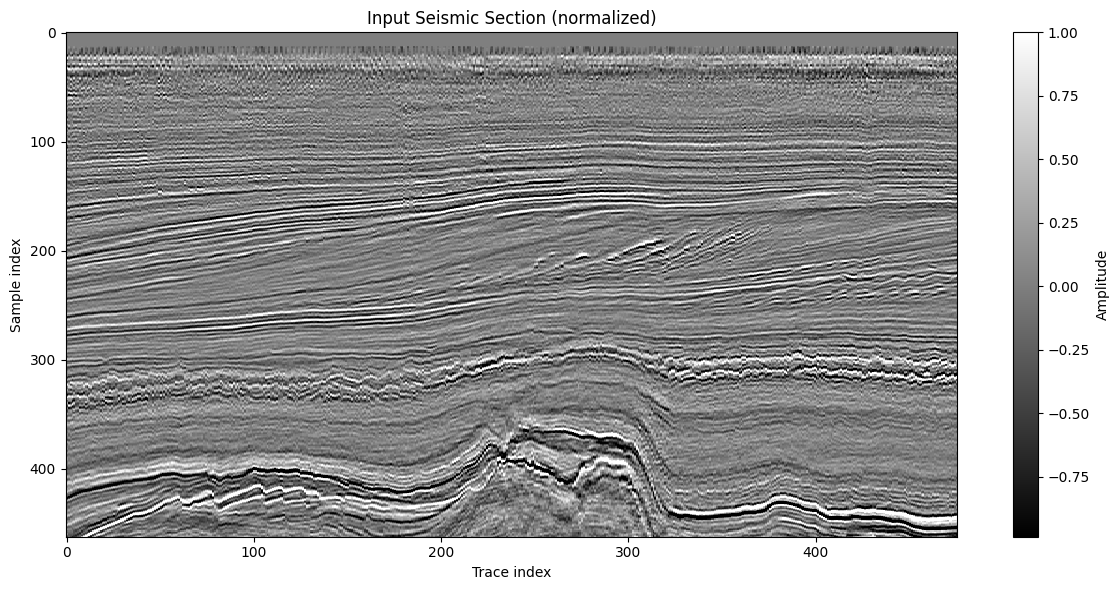

In [11]:
plt.figure(figsize=(12, 6))
plt.imshow(seis2d, cmap='gray', aspect='auto', interpolation='nearest')
plt.title('Input Seismic Section (normalized)')
plt.xlabel('Trace index')
plt.ylabel('Sample index')
plt.colorbar(label='Amplitude')
plt.tight_layout()
plt.show()

In [12]:
FAULTSEG_DIR = PROJECT_ROOT / 'faultSeg_2019_pyTorch'
FAULTSEG_NOTEBOOK = FAULTSEG_DIR / 'prediction_pytorch_F3.ipynb'
FAULTSEG_OUTPUT_DIR = WORK_DIR / 'faultseg_outputs'
FAULTSEG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

faultseg_inline_npy = FAULTSEG_OUTPUT_DIR / 'faultseg_inline.npy'
faultseg_inline_dat = FAULTSEG_OUTPUT_DIR / 'faultseg_inline.dat'
executed_faultseg_notebook = FAULTSEG_OUTPUT_DIR / 'prediction_pytorch_F3.executed.ipynb'

cmd = [
    sys.executable,
    '-m', 'jupyter', 'nbconvert',
    '--to', 'notebook',
    '--execute',
    '--output', executed_faultseg_notebook.name,
    '--output-dir', str(FAULTSEG_OUTPUT_DIR),
    str(FAULTSEG_NOTEBOOK),
]

env = os.environ.copy()
env['OSV_SGY_PATH'] = str(SGY_PATH)
env['OSV_FAULTSEG_OUTPUT_DIR'] = str(FAULTSEG_OUTPUT_DIR)
env['OSV_TARGET_INLINE'] = str(int(iline_id))

print('Running fault segmentation notebook:')
print(' '.join(cmd))

proc_faultseg = subprocess.run(
    cmd,
    cwd=str(FAULTSEG_DIR),
    text=True,
    capture_output=True,
    check=True,
    env=env,
)

print(proc_faultseg.stdout if proc_faultseg.stdout else 'faultSeg completed with no stdout.')
if proc_faultseg.stderr:
    print('stderr:')
    print(proc_faultseg.stderr)

print('FaultSeg inline output:', faultseg_inline_npy)
print('Exists:', faultseg_inline_npy.exists(), 'DAT exists:', faultseg_inline_dat.exists())

Running fault segmentation notebook:
/home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/.venv/bin/python -m jupyter nbconvert --to notebook --execute --output prediction_pytorch_F3.executed.ipynb --output-dir /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime/faultseg_outputs /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/faultSeg_2019_pyTorch/prediction_pytorch_F3.ipynb
faultSeg completed with no stdout.
stderr:
[NbConvertApp] Converting notebook /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/faultSeg_2019_pyTorch/prediction_pytorch_F3.ipynb to notebook
[NbConvertApp] Writing 21519 bytes to /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime/faultseg_outputs/prediction_pytorch_F3.executed.ipynb

FaultSeg inline output: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime/faultseg_outputs/faultseg_inline.npy
Exists: True DAT exists: 

In [23]:
import json

faultseg_volume_path = FAULTSEG_OUTPUT_DIR / 'faultseg_volume.npy'
seismic_volume_path = FAULTSEG_OUTPUT_DIR / 'seismic_volume.npy'
faultseg_volume_meta_path = FAULTSEG_OUTPUT_DIR / 'faultseg_volume_meta.json'

RUN_FULL_VOLUME_FAULTSEG = False

if faultseg_volume_meta_path.exists() and faultseg_volume_path.exists() and seismic_volume_path.exists():
    volume_meta = json.loads(faultseg_volume_meta_path.read_text(encoding='utf-8'))
    print('Using cached full 3D FaultSeg volume:')
    print(json.dumps({
        'n1': volume_meta['n1'],
        'n2': volume_meta['n2'],
        'n3': volume_meta['n3'],
        'device': volume_meta['device'],
        'fault_volume_npy': volume_meta['fault_volume_npy'],
    }, indent=2))
elif RUN_FULL_VOLUME_FAULTSEG:
    if str(FAULTSEG_DIR) not in sys.path:
        sys.path.insert(0, str(FAULTSEG_DIR))
    from predict_sgy_inline import run_full_volume_prediction

    volume_meta = run_full_volume_prediction(
        sgy_path=SGY_PATH,
        output_dir=FAULTSEG_OUTPUT_DIR,
        chunk_inlines=128,
        chunk_overlap=32,
    )
    print('Computed full 3D FaultSeg volume:')
    print(json.dumps({
        'n1': volume_meta['n1'],
        'n2': volume_meta['n2'],
        'n3': volume_meta['n3'],
        'device': volume_meta['device'],
        'fault_volume_npy': volume_meta['fault_volume_npy'],
    }, indent=2))
else:
    volume_meta = None
    print(
        'Full 3D FaultSeg volume not computed yet. '
        'Set RUN_FULL_VOLUME_FAULTSEG=True in this cell to generate it '
        '(cached to faultseg_outputs/faultseg_volume.npy).'
    )

Full 3D FaultSeg volume not computed yet. Set RUN_FULL_VOLUME_FAULTSEG=True in this cell to generate it (cached to faultseg_outputs/faultseg_volume.npy).


In [13]:
# Write input for Java OSV runner as big-endian float32 with layout [n2][n1]
in_dat = WORK_DIR / 'input_slice.dat'
out_dir = WORK_DIR / 'osv_outputs'
out_dir.mkdir(parents=True, exist_ok=True)

seis2d.T.astype('>f4').tofile(in_dat)

# ── Load raw FaultSeg probability ─────────────────────────────────────────
faultseg_inline_used_npy = FAULTSEG_OUTPUT_DIR / 'faultseg_inline_osv.npy'
faultseg_inline_used_dat = FAULTSEG_OUTPUT_DIR / 'faultseg_inline_osv.dat'

fa_raw = np.nan_to_num(np.load(faultseg_inline_npy).astype(np.float32),
                       nan=0.0, posinf=0.0, neginf=0.0)

# Match shape to the decimated OSV grid (no flipping or shifting — FaultSeg
# was run on the same inline so it is already spatially registered).
if fa_raw.shape != (n1, n2):
    if fa_raw.shape[0] == n1 and fa_raw.shape[1] >= n2:
        if step > 1 and fa_raw.shape[1] != n2:
            fa_raw = fa_raw[:, ::step]
        fa_raw = fa_raw[:, :n2]
    else:
        raise ValueError(
            f'Cannot match faultSeg shape {fa_raw.shape} to seismic shape {(n1, n2)}'
        )

fa_raw = np.clip(fa_raw, 0.0, 1.0)

# ── Diagnostic: inspect the raw probability distribution ──────────────────
print('Raw FaultSeg statistics:')
print(f'  shape : {fa_raw.shape}')
print(f'  mean  : {fa_raw.mean():.3f}   std: {fa_raw.std():.3f}')
for thr in [0.3, 0.5, 0.7, 0.8, 0.9]:
    pct = 100.0 * float(np.mean(fa_raw > thr))
    print(f'  > {thr:.1f} : {pct:.1f}%')

# ── Power-law sharpening ───────────────────────────────────────────────────
# Raise probability to a power p > 1 to suppress the diffuse background
# while preserving high-confidence fault detections.
#
# p=2 balances signal preservation against background suppression:
#   p=1  → raw output (~29% above 0.5, too diffuse for OSV)
#   p=2  → ~8%  above 0.5  (good coverage for OSV scoring)
#   p=3  → ~3%  above 0.5  (over-suppressed; OSV loses context)
#
# Note: OSV2DRunner.java uses the seismic linearity for orientation
# estimation regardless of this power, so moderately diffuse input is fine.
SHARPEN_POWER = 2.0
fa_for_osv = np.power(fa_raw, SHARPEN_POWER).astype(np.float32)
fa_for_osv = np.clip(fa_for_osv, 0.0, 1.0)

print(f'\nAfter power-law sharpening (p={SHARPEN_POWER}):')
print(f'  mean  : {fa_for_osv.mean():.4f}')
for thr in [0.1, 0.3, 0.5]:
    pct = 100.0 * float(np.mean(fa_for_osv > thr))
    print(f'  > {thr:.1f} : {pct:.1f}%')

np.save(faultseg_inline_used_npy, fa_for_osv)
# Write to .dat in big-endian float32, transposed to [n2][n1] for Java:
#   Python layout : fa_for_osv[i_sample, i_trace]  shape (n1, n2)
#   .dat on disk  : fa_for_osv.T  [i_trace, i_sample]  row-major → Java reads
#                   float[n2][n1] where data[i2][i1] = fault @ trace i2, sample i1
fa_for_osv.T.astype('>f4').tofile(faultseg_inline_used_dat)

# ── Run Java OSV2DRunner ───────────────────────────────────────────────────
# Args: <inputDat> <outputDir> <n1> <n2> [faultScoreDat]
# OSV2DRunner v2: uses seismic linearity for orientation scanning and
# FaultSeg probability as the voting score (see tools/OSV2DRunner.java).
cmd = [
    'java',
    '--class-path', 'libs/*:build/classes',
    'tools/OSV2DRunner.java',
    str(in_dat),
    str(out_dir),
    str(n1),
    str(n2),
    str(faultseg_inline_used_dat),
]

print('\nRunning OSV2DRunner:')
print(' '.join(cmd))

proc = subprocess.run(
    cmd,
    cwd=str(PROJECT_ROOT),
    text=True,
    capture_output=True,
    check=True,
)

print(proc.stdout if proc.stdout else 'OSV completed with no stdout.')
if proc.stderr:
    print('stderr:', proc.stderr)


Raw FaultSeg statistics:
  shape : (463, 476)
  mean  : 0.344   std: 0.264
  > 0.3 : 48.7%
  > 0.5 : 28.6%
  > 0.7 : 12.9%
  > 0.8 : 7.0%
  > 0.9 : 2.6%

After power-law sharpening (p=2.0):
  mean  : 0.1881
  > 0.1 : 46.9%
  > 0.3 : 24.4%
  > 0.5 : 12.4%

Running OSV2DRunner:
java --class-path libs/*:build/classes tools/OSV2DRunner.java /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime/input_slice.dat /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime/osv_outputs 463 476 /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime/faultseg_outputs/faultseg_inline_osv.dat
0/12 done...
1/12 done...
2/12 done...
3/12 done...
4/12 done...
5/12 done...
6/12 done...
7/12 done...
8/12 done...
9/12 done...
10/12 done...
11/12 done...
12/12 done...
0/12 done...
1/12 done...
2/12 done...
3/12 done...
4/12 done...
5/12 done...
6/12 done...
7/12 done...
8/12 done...
9/12 done...
10/12 done...
11/12 d

In [25]:
def read_dat_2d(path, n1, n2):
    arr = np.fromfile(path, dtype='>f4')
    if arr.size != n1 * n2:
        raise ValueError(f'Unexpected size for {path}: {arr.size}, expected {n1*n2}')
    return arr.reshape(n2, n1).T

# Load the original (raw, unsharpened) FaultSeg probability for display —
# this lets you see the model's native output before power-law conditioning.
fa = np.nan_to_num(np.load(faultseg_inline_npy).astype(np.float32),
                   nan=0.0, posinf=0.0, neginf=0.0)
if fa.shape != (n1, n2):
    if fa.shape[0] == n1 and fa.shape[1] >= n2:
        if step > 1 and fa.shape[1] != n2:
            fa = fa[:, ::step]
        fa = fa[:, :n2]
    else:
        raise ValueError(f'Unexpected faultseg shape {fa.shape}, expected {(n1, n2)}')
fa = np.clip(fa, 0.0, 1.0)

# Load OSV outputs — trust OSV's own orientation-guided filtering.
# OSV2DRunner internally runs FaultOrientScanner2 (dip estimation + NMS) and
# applies a guided post-filter; no additional Python-side masking is needed.
fv   = np.nan_to_num(read_dat_2d(out_dir / 'fv.dat',  n1, n2), nan=0.0)
fvt  = np.nan_to_num(read_dat_2d(out_dir / 'fvt.dat', n1, n2), nan=0.0)
el   = np.nan_to_num(read_dat_2d(out_dir / 'el.dat',  n1, n2), nan=1.0)

fvg_path  = out_dir / 'fvg.dat'
fvtg_path = out_dir / 'fvtg.dat'
if fvg_path.exists() and fvtg_path.exists():
    fvg  = np.nan_to_num(read_dat_2d(fvg_path,  n1, n2), nan=0.0)
    fvtg = np.nan_to_num(read_dat_2d(fvtg_path, n1, n2), nan=0.0)
else:
    fvg  = fv.copy()
    fvtg = fvt.copy()

OSV_EXTRACT_THRESHOLD = 0.20
fvtg_binary = (fvtg >= OSV_EXTRACT_THRESHOLD).astype(np.float32)

print('Loaded outputs:', sorted([p.name for p in out_dir.glob('*.dat')]))
print(f'faultseg (raw) range : {fa.min():.3f} – {fa.max():.3f}')
print(f'fv  range            : {fv.min():.3f} – {fv.max():.3f}')
print(f'fvg range            : {fvg.min():.3f} – {fvg.max():.3f}')
print(f'fvt range            : {fvt.min():.3f} – {fvt.max():.3f}')
print(f'fvtg range           : {fvtg.min():.3f} – {fvtg.max():.3f}')
print(f'OSV_EXTRACT_THRESHOLD: {OSV_EXTRACT_THRESHOLD:.2f}')
print('Non-zero counts:', {
    'faultseg_raw': int(np.count_nonzero(fa)),
    'fv':           int(np.count_nonzero(fv)),
    'fvg':          int(np.count_nonzero(fvg)),
    'fvt':          int(np.count_nonzero(fvt)),
    'fvtg':         int(np.count_nonzero(fvtg)),
    'fvtg_binary':  int(np.count_nonzero(fvtg_binary)),
})

Loaded outputs: ['el.dat', 'fa.dat', 'ft.dat', 'fv.dat', 'fvg.dat', 'fvt.dat', 'fvtg.dat', 'pt.dat']
faultseg (raw) range : 0.000 – 1.000
fv  range            : 0.000 – 1.000
fvg range            : 0.000 – 1.000
fvt range            : 0.000 – 1.000
fvtg range           : 0.000 – 1.000
OSV_EXTRACT_THRESHOLD: 0.20
Non-zero counts: {'faultseg_raw': 220388, 'fv': 91590, 'fvg': 80761, 'fvt': 6738, 'fvtg': 4273, 'fvtg_binary': 1820}


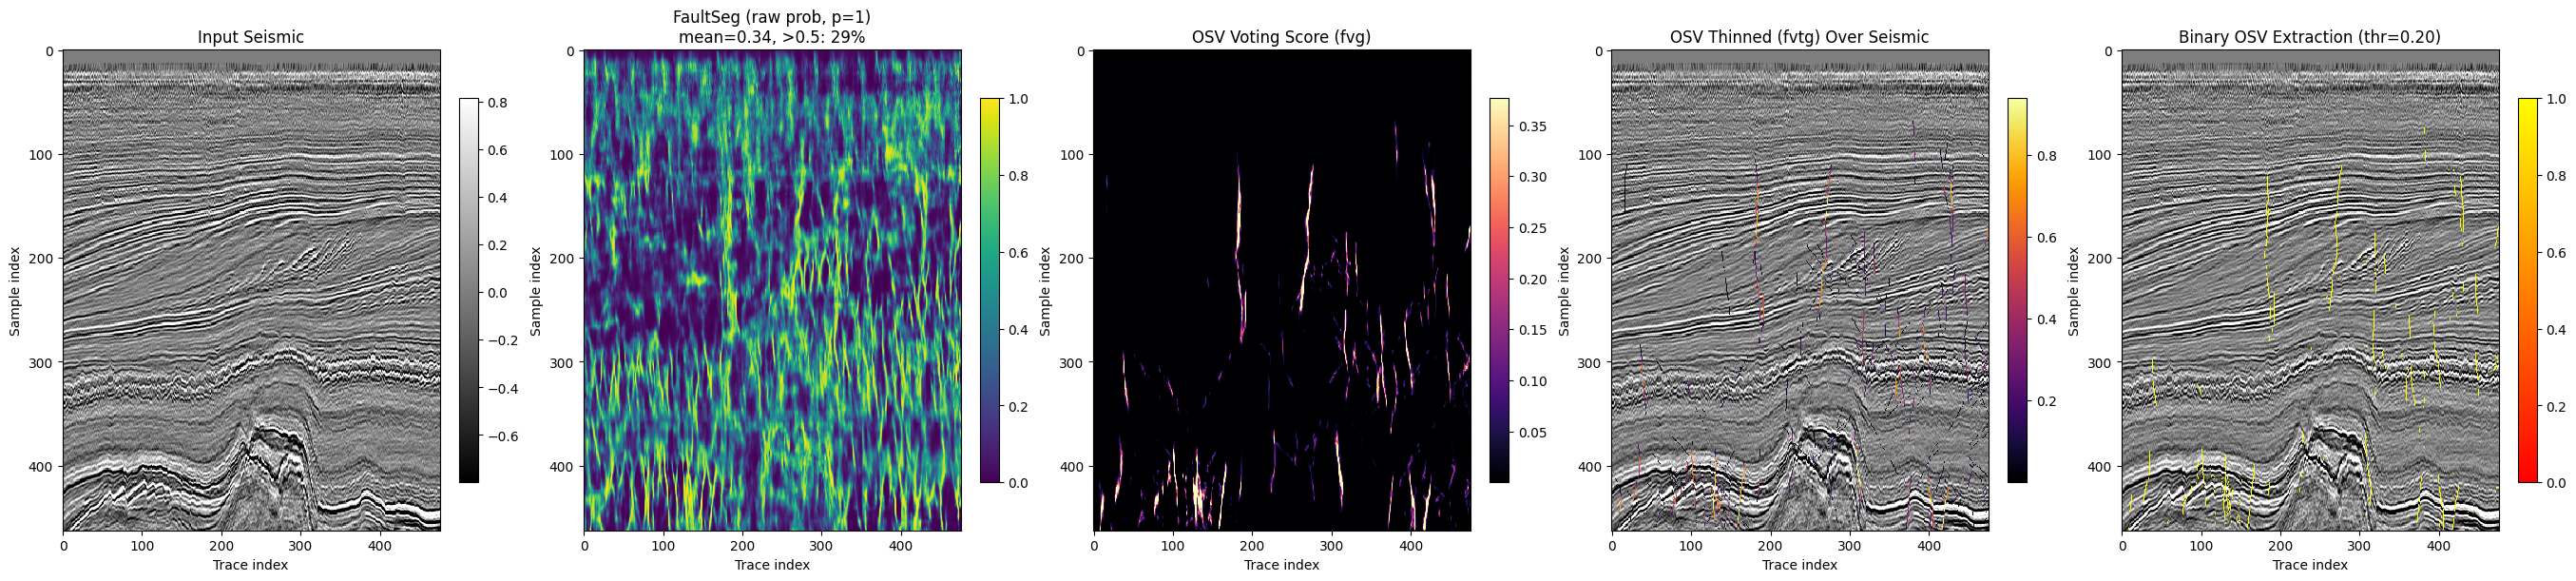

fvg  non-zero: 80761/220388  (36.6%)  vmin=0.0000  vmax=0.3767
fvtg non-zero: 4273/220388  (1.9%)
fvtg_binary non-zero: 1820/220388  (0.8%)


In [26]:
def robust_limits(x, lo=0.02, hi=0.98):
    finite = x[np.isfinite(x)]
    if finite.size == 0:
        return 0.0, 1.0
    vmin, vmax = np.quantile(finite, [lo, hi])
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)

def nonzero_limits(x, lo_pct=2, hi_pct=99):
    """Display limits computed only from non-zero pixels.
    Ensures sparse fault features are not crushed to black when most of
    the image is background (zero)."""
    nz = x[x > 0]
    if nz.size == 0:
        return 0.0, 1.0
    vmin = np.percentile(nz, lo_pct)
    vmax = np.percentile(nz, hi_pct)
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)

seis_vmin, seis_vmax = robust_limits(seis2d, 0.02, 0.98)
fa_vmin, fa_vmax = 0.0, 1.0          # absolute probability scale for FaultSeg

# OSV voting score: use non-zero limits so sparse fault ridges appear bright
fvg_vmin,  fvg_vmax  = nonzero_limits(fvg,  2, 98)
fvtg_vmin, fvtg_vmax = nonzero_limits(fvtg, 2, 99)

# Mask zero / near-zero OSV values for the overlay so the seismic shows through
fvtg_overlay = np.ma.masked_where(fvtg <= max(fvtg_vmin * 0.5, 1e-8), fvtg)
fvtg_binary_overlay = np.ma.masked_where(fvtg_binary <= 0.0, fvtg_binary)
overlay_cmap  = plt.cm.inferno.copy()
overlay_cmap.set_bad(alpha=0.0)
binary_cmap = plt.cm.autumn.copy()
binary_cmap.set_bad(alpha=0.0)

fig, axes = plt.subplots(1, 5, figsize=(27, 6), constrained_layout=True)

# Panel 1 — input seismic
im0 = axes[0].imshow(seis2d, cmap='gray', aspect='auto', interpolation='nearest',
                     vmin=seis_vmin, vmax=seis_vmax)
axes[0].set_title('Input Seismic')
axes[0].set_xlabel('Trace index'); axes[0].set_ylabel('Sample index')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Panel 2 — raw FaultSeg probability (fixed 0–1 colourbar)
im1 = axes[1].imshow(fa, cmap='viridis', aspect='auto', interpolation='nearest',
                     vmin=fa_vmin, vmax=fa_vmax)
axes[1].set_title(f'FaultSeg (raw prob, p=1)\n'
                  f'mean={fa.mean():.2f}, >0.5: {100*np.mean(fa>0.5):.0f}%')
axes[1].set_xlabel('Trace index'); axes[1].set_ylabel('Sample index')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Panel 3 — OSV voting score on sharpened FaultSeg
im2 = axes[2].imshow(fvg, cmap='magma', aspect='auto', interpolation='nearest',
                     vmin=fvg_vmin, vmax=fvg_vmax)
axes[2].set_title('OSV Voting Score (fvg)')
axes[2].set_xlabel('Trace index'); axes[2].set_ylabel('Sample index')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

# Panel 4 — continuous OSV thinned overlay on seismic
axes[3].imshow(seis2d, cmap='gray', aspect='auto', interpolation='nearest',
               vmin=seis_vmin, vmax=seis_vmax)
im3 = axes[3].imshow(fvtg_overlay, cmap=overlay_cmap, aspect='auto',
                     interpolation='nearest', vmin=fvtg_vmin, vmax=fvtg_vmax)
axes[3].set_title('OSV Thinned (fvtg) Over Seismic')
axes[3].set_xlabel('Trace index'); axes[3].set_ylabel('Sample index')
plt.colorbar(im3, ax=axes[3], shrink=0.8)

# Panel 5 — thresholded binary extraction
axes[4].imshow(seis2d, cmap='gray', aspect='auto', interpolation='nearest',
               vmin=seis_vmin, vmax=seis_vmax)
im4 = axes[4].imshow(fvtg_binary_overlay, cmap=binary_cmap, aspect='auto',
                     interpolation='nearest', vmin=0.0, vmax=1.0)
axes[4].set_title(f'Binary OSV Extraction (thr={OSV_EXTRACT_THRESHOLD:.2f})')
axes[4].set_xlabel('Trace index'); axes[4].set_ylabel('Sample index')
plt.colorbar(im4, ax=axes[4], shrink=0.8)

plt.show()
print(f'fvg  non-zero: {np.count_nonzero(fvg)}/{fvg.size}  '
      f'({100*np.mean(fvg>0):.1f}%)  vmin={fvg_vmin:.4f}  vmax={fvg_vmax:.4f}')
print(f'fvtg non-zero: {np.count_nonzero(fvtg)}/{fvtg.size}  '
      f'({100*np.mean(fvtg>0):.1f}%)')
print(f'fvtg_binary non-zero: {np.count_nonzero(fvtg_binary)}/{fvtg_binary.size}  '
      f'({100*np.mean(fvtg_binary>0):.1f}%)')

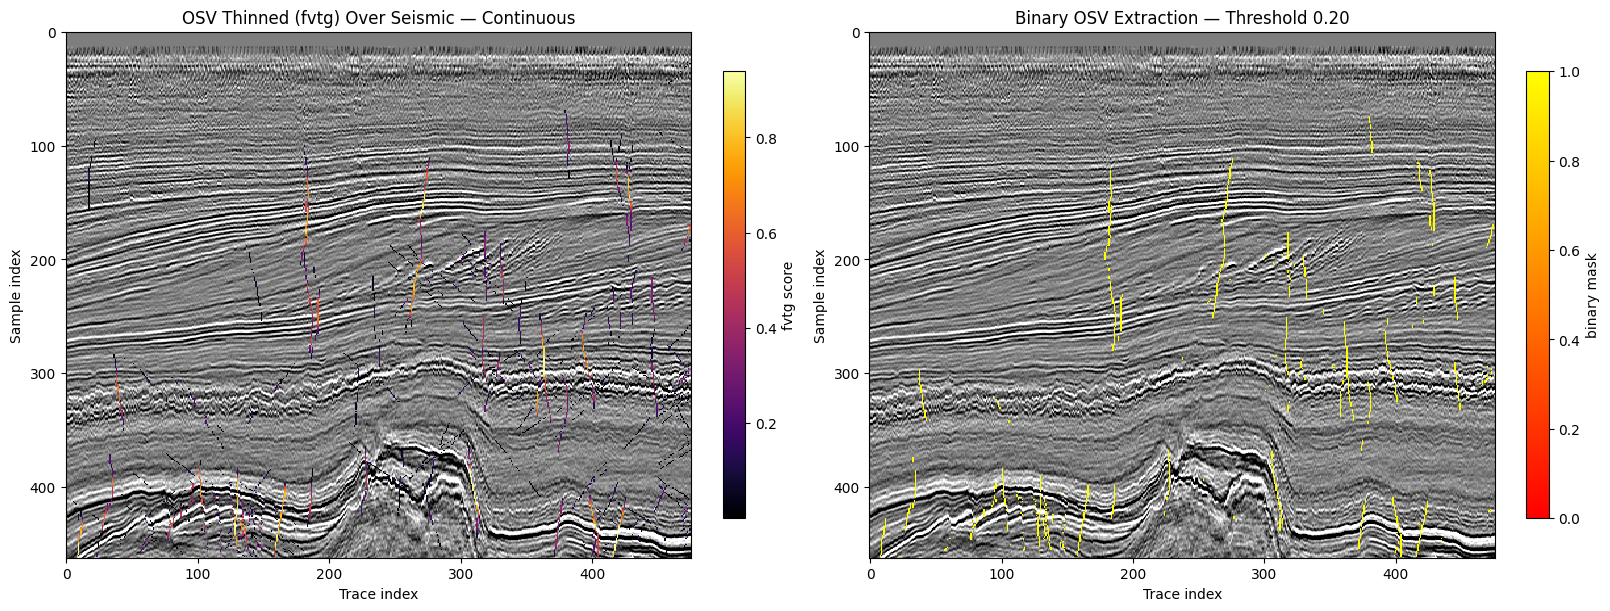

Saved preview plot: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime/osv_preview.png
Saved binary preview plot: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/notebooks/osv_runtime/osv_preview_binary.png


In [27]:
preview_path = WORK_DIR / 'osv_preview.png'
preview_binary_path = WORK_DIR / 'osv_preview_binary.png'

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axes[0].imshow(
    seis2d,
    cmap='gray',
    aspect='auto',
    interpolation='nearest',
    vmin=seis_vmin,
    vmax=seis_vmax,
)
im0 = axes[0].imshow(
    fvtg_overlay,
    cmap=overlay_cmap,
    aspect='auto',
    interpolation='nearest',
    vmin=fvtg_vmin,
    vmax=fvtg_vmax,
)
axes[0].set_title('OSV Thinned (fvtg) Over Seismic — Continuous')
axes[0].set_xlabel('Trace index')
axes[0].set_ylabel('Sample index')
fig.colorbar(im0, ax=axes[0], shrink=0.85, label='fvtg score')

axes[1].imshow(
    seis2d,
    cmap='gray',
    aspect='auto',
    interpolation='nearest',
    vmin=seis_vmin,
    vmax=seis_vmax,
)
im1 = axes[1].imshow(
    fvtg_binary_overlay,
    cmap=binary_cmap,
    aspect='auto',
    interpolation='nearest',
    vmin=0.0,
    vmax=1.0,
)
axes[1].set_title(f'Binary OSV Extraction — Threshold {OSV_EXTRACT_THRESHOLD:.2f}')
axes[1].set_xlabel('Trace index')
axes[1].set_ylabel('Sample index')
fig.colorbar(im1, ax=axes[1], shrink=0.85, label='binary mask')

fig.savefig(preview_path, dpi=180)
fig.savefig(preview_binary_path, dpi=180)
plt.show()
print('Saved preview plot:', preview_path)
print('Saved binary preview plot:', preview_binary_path)

In [ ]:
print('Fresh clone setup: regenerate Java classes before running this notebook:')
print('  gradle classes')

Inline 425: 951 total traces, 476 decimated (step=2), n2=476
Sample interval: 4000 µs
Exporting binary extraction with OSV_EXTRACT_THRESHOLD=0.20
  fvg.sgy  976 KB
  fvtg.sgy  976 KB
  fvtg_binary.sgy  976 KB
  fa.sgy  976 KB
Round-trip max abs error (fvg): 5.22e-08  (PASS)
Round-trip max abs error (fvtg_binary): 0.00e+00  (PASS)
